# XGBoost

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print("Environment setup and imports completed.")

Environment setup and imports completed.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/ML Assignment"
FINAL_MODEL_DIR = os.path.join(BASE_DIR, "final_dataset")

XGB_DIR = os.path.join(BASE_DIR, "xgboost")

os.makedirs(XGB_DIR, exist_ok=True)

print("Final Model Directory :", FINAL_MODEL_DIR)
print("XGBoost Model Dir     :", XGB_DIR)

Mounted at /content/drive
Final Model Directory : /content/drive/MyDrive/ML Assignment/final_dataset
XGBoost Model Dir     : /content/drive/MyDrive/ML Assignment/xgboost


In [ ]:
X_train_final = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_train_tree.csv")
)

X_val_final = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_validation_tree.csv")
)

X_test_final = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_test_tree.csv")
)

# Drop all market columns
market_cols_to_drop = [c for c in X_train_final.columns if c.startswith("market_")]
X_train_final = X_train_final.drop(columns=market_cols_to_drop, errors="ignore")
X_val_final = X_val_final.drop(columns=market_cols_to_drop, errors="ignore")
X_test_final = X_test_final.drop(columns=market_cols_to_drop, errors="ignore")

print(f"Dropped {len(market_cols_to_drop)} market columns successfully.")

y_train_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_train.csv")
).squeeze("columns")

y_val_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_validation.csv")
).squeeze("columns")

y_test_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_test.csv")
).squeeze("columns")

target_encoder = joblib.load(
    os.path.join(FINAL_MODEL_DIR, "target_encoder.joblib")
)

print("Matrix Shapes:")
print(f"Training   : {X_train_final.shape} | Labels: {y_train_encoded.shape}")
print(f"Validation : {X_val_final.shape} | Labels: {y_val_encoded.shape}")
print(f"Test       : {X_test_final.shape} | Labels: {y_test_encoded.shape}")

print("\nTarget Class Mapping:")
for idx, label in enumerate(target_encoder.classes_):
    print(f"  {idx} -> {label}")

train_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

print("Training sample weights computed successfully.")
print(f"Sample weights shape: {train_sample_weights.shape}")

Dropped 7 market columns successfully.
Matrix Shapes:
Training   : (17294, 86) | Labels: (17294,)
Validation : (3818, 86) | Labels: (3818,)
Test       : (3859, 86) | Labels: (3859,)

Target Class Mapping:
  0 -> Away Win
  1 -> Draw
  2 -> Home Win
Training sample weights computed successfully.
Sample weights shape: (17294,)


Verify Final Data

In [ ]:
assert list(X_train_final.columns) == list(X_val_final.columns)
assert list(X_train_final.columns) == list(X_test_final.columns)

assert len(X_train_final) == len(y_train_encoded)
assert len(X_val_final) == len(y_val_encoded)
assert len(X_test_final) == len(y_test_encoded)

assert X_train_final.isnull().sum().sum() == 0
assert X_val_final.isnull().sum().sum() == 0
assert X_test_final.isnull().sum().sum() == 0

assert np.isfinite(
    X_train_final.select_dtypes(include=np.number)
).all().all()

print("Final XGBoost input verification passed.")

print("\nFeature count:", X_train_final.shape[1])
print("Training rows:", len(X_train_final))
print("Validation rows:", len(X_val_final))
print("Test rows:", len(X_test_final))

Final XGBoost input verification passed.

Feature count: 86
Training rows: 17294
Validation rows: 3818
Test rows: 3859


Correlation Filter (Fit using training data only)

In [ ]:
CORR_THRESHOLD = 0.90

corr_matrix = X_train_final.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

protected = {c for c in X_train_final.columns if c.startswith("market_")}
protected.discard("market_away_probability")  # exactly redundant, since the three probabilities sum to 1

corr_drop_columns = [
    col for col in upper_triangle.columns
    if (upper_triangle[col] > CORR_THRESHOLD).any() and col not in protected
]
if "market_away_probability" in X_train_final.columns:
    corr_drop_columns.append("market_away_probability")

X_train_corr = X_train_final.drop(
    columns=corr_drop_columns,
    errors="ignore"
).copy()

X_val_corr = X_val_final.drop(
    columns=corr_drop_columns,
    errors="ignore"
).copy()

X_test_corr = X_test_final.drop(
    columns=corr_drop_columns,
    errors="ignore"
).copy()

print("Correlation threshold:", CORR_THRESHOLD)

print(
    "Features before correlation filtering:",
    X_train_final.shape[1]
)

print(
    "Features removed:",
    len(corr_drop_columns)
)

print(
    "Features remaining:",
    X_train_corr.shape[1]
)

assert list(X_train_corr.columns) == list(X_val_corr.columns)
assert list(X_train_corr.columns) == list(X_test_corr.columns)

Correlation threshold: 0.9
Features before correlation filtering: 86
Features removed: 18
Features remaining: 68


Weighted Feature selection

In [ ]:
XGB_TARGET_FEATURES = min(
    50,
    X_train_corr.shape[1]
)

xgb_selector_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    importance_type="gain",
    random_state=42,
    n_jobs=-1
)

xgb_selector = SelectFromModel(
    estimator=xgb_selector_model,
    threshold=-np.inf,
    max_features=XGB_TARGET_FEATURES
)

# Fit selector with balanced sample weights
xgb_selector.fit(
    X_train_corr,
    y_train_encoded,
    sample_weight=train_sample_weights
)

xgb_selected_features = (
    X_train_corr.columns[
        xgb_selector.get_support()
    ].tolist()
)

print(
    "XGBoost Gain selected:",
    len(xgb_selected_features),
    "features"
)

print("\nSelected features:")
for i, feature in enumerate(xgb_selected_features, start=1):
    print(f"{i:2d}. {feature}")

XGBoost Gain selected: 50 features

Selected features:
 1. home_win_rate
 2. home_draw_rate
 3. home_loss_rate
 4. home_goals_for_per_match
 5. home_goals_against_per_match
 6. home_home_win_rate
 7. home_home_draw_rate
 8. home_home_goals_against_per_match
 9. home_points_last3
10. home_points_last5
11. home_points_last10
12. home_goals_for_last10
13. home_goals_against_last5
14. home_goals_against_last10
15. home_elo_before
16. away_win_rate
17. away_loss_rate
18. away_goals_for_per_match
19. away_goals_against_per_match
20. away_away_win_rate
21. away_away_draw_rate
22. away_away_goals_for_per_match
23. away_away_goals_against_per_match
24. away_points_last3
25. away_points_last10
26. away_goals_for_last3
27. away_goals_for_last10
28. away_elo_before
29. win_rate_difference
30. draw_rate_difference
31. goals_for_difference
32. goals_against_difference
33. venue_win_rate_difference
34. venue_goals_for_difference
35. venue_goals_against_difference
36. points_last3_difference
37. goals

In [ ]:
X_train_xgb = X_train_corr[
    xgb_selected_features
].copy()

X_val_xgb = X_val_corr[
    xgb_selected_features
].copy()

X_test_xgb = X_test_corr[
    xgb_selected_features
].copy()

print("\nSelected Matrix Shapes:")
print("Training   :", X_train_xgb.shape)
print("Validation :", X_val_xgb.shape)
print("Test       :", X_test_xgb.shape)


Selected Matrix Shapes:
Training   : (17294, 50)
Validation : (3818, 50)
Test       : (3859, 50)


Baseline XGBoost (Weighted + Calibrated Threshold)

In [ ]:
# Vectorized helper: predict Draw (1) if P(Draw) >= threshold,
# otherwise Home Win (2) if P(Home) >= P(Away), else Away Win (0)
def predict_with_draw_threshold(probabilities, threshold=0.30):
    p = np.asarray(probabilities)
    return np.where(
        p[:, 1] >= threshold,        # Draw
        1,
        np.where(p[:, 2] >= p[:, 0], 2, 0)   # Home Win (2) or Away Win (0)
    )

xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Fit baseline with balanced sample weights
xgb_baseline.fit(
    X_train_xgb,
    y_train_encoded,
    sample_weight=train_sample_weights
)

# Predict probabilities
y_train_proba_base = xgb_baseline.predict_proba(X_train_xgb)
y_val_proba_base = xgb_baseline.predict_proba(X_val_xgb)

# Calibrate optimal baseline draw threshold on validation set using a unified grid
thr_grid = np.linspace(0.20, 0.42, 23)
base_threshold = 0.33
best_base_f1 = 0.0

for t in thr_grid:
    temp_preds = predict_with_draw_threshold(y_val_proba_base, threshold=t)
    score = f1_score(y_val_encoded, temp_preds, average="macro", zero_division=0)
    if score > best_base_f1:
        best_base_f1 = score
        base_threshold = t

if base_threshold in (thr_grid[0], thr_grid[-1]):
    print("WARNING: threshold is at the edge of the grid, widen the search range.")

print(f"Calibrated Baseline Draw Threshold: {base_threshold:.3f}")

# Generate baseline predictions using calibrated cutoff
y_train_pred_base = predict_with_draw_threshold(y_train_proba_base, threshold=base_threshold)
y_val_pred_base = predict_with_draw_threshold(y_val_proba_base, threshold=base_threshold)

Calibrated Baseline Draw Threshold: 0.380


Baseline Validation Metrics

In [ ]:
baseline_train_accuracy = accuracy_score(
    y_train_encoded,
    y_train_pred_base
)

baseline_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_base
)

baseline_macro_precision = precision_score(
    y_val_encoded,
    y_val_pred_base,
    average="macro",
    zero_division=0
)

baseline_macro_recall = recall_score(
    y_val_encoded,
    y_val_pred_base,
    average="macro",
    zero_division=0
)

baseline_macro_f1 = f1_score(
    y_val_encoded,
    y_val_pred_base,
    average="macro",
    zero_division=0
)

baseline_weighted_f1 = f1_score(
    y_val_encoded,
    y_val_pred_base,
    average="weighted",
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_val_encoded,
    y_val_proba_base,
    multi_class="ovr",
    average="weighted"
)

print("=" * 60)
print("BASELINE XGBOOST VALIDATION")
print("=" * 60)

print(
    f"Training Accuracy : "
    f"{baseline_train_accuracy:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{baseline_val_accuracy:.4f}"
)

print(
    f"Macro Precision   : "
    f"{baseline_macro_precision:.4f}"
)

print(
    f"Macro Recall      : "
    f"{baseline_macro_recall:.4f}"
)

print(
    f"Macro F1          : "
    f"{baseline_macro_f1:.4f}"
)

print(
    f"Weighted F1       : "
    f"{baseline_weighted_f1:.4f}"
)

print(
    f"ROC-AUC           : "
    f"{baseline_roc_auc:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_val_encoded,
        y_val_pred_base,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

BASELINE XGBOOST VALIDATION
Training Accuracy : 0.6270
Validation Accuracy: 0.4688
Macro Precision   : 0.4375
Macro Recall      : 0.4444
Macro F1          : 0.4385
Weighted F1       : 0.4670
ROC-AUC           : 0.6579

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.45      0.55      0.50      1131
        Draw       0.27      0.24      0.25       955
    Home Win       0.59      0.54      0.57      1732

    accuracy                           0.47      3818
   macro avg       0.44      0.44      0.44      3818
weighted avg       0.47      0.47      0.47      3818



Baseline Validation Confusion Matrix

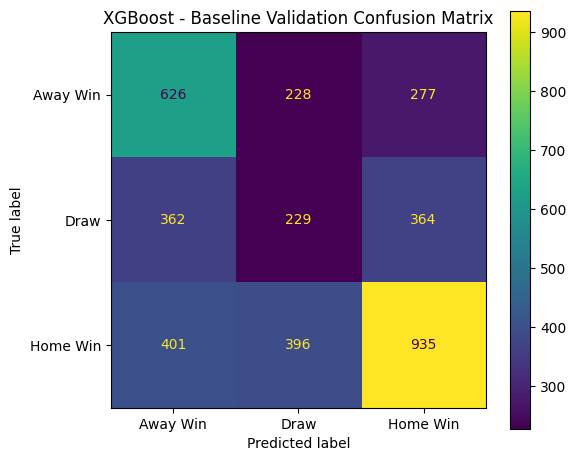

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val_encoded,
    y_val_pred_base,
    display_labels=target_encoder.classes_,
    ax=ax
)

plt.title(
    "XGBoost - Baseline Validation Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        XGB_DIR,
        "baseline_confusion_matrix.png"
    ),
    dpi=300
)

plt.show()

Anti-Leakage XGBoost Pipeline

In [ ]:
xgb_pipeline = Pipeline([
    (
        "selector",
        SelectFromModel(
            estimator=XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                min_child_weight=3,

                subsample=0.8,
                colsample_bytree=0.8,

                objective="multi:softprob",
                eval_metric="mlogloss",
                importance_type="gain",

                random_state=42,
                n_jobs=1
            ),

            threshold=-np.inf,
            max_features=XGB_TARGET_FEATURES
        )
    ),

    (
        "classifier",
        XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",

            random_state=42,
            n_jobs=1
        )
    )
])

print("XGBoost pipeline created.")

XGBoost pipeline created.


XGBoost Hyperparameter Space

In [ ]:
param_distributions = {

    "classifier__n_estimators": [
        200, 300, 400, 500, 600
    ],

    "classifier__max_depth": [
        2, 3, 4, 5, 6
    ],

    "classifier__learning_rate": [
        0.01, 0.03, 0.05, 0.08, 0.10
    ],

    "classifier__min_child_weight": [
        1, 3, 5, 7, 10
    ],

    "classifier__subsample": [
        0.7, 0.8, 0.9, 1.0
    ],

    "classifier__colsample_bytree": [
        0.6, 0.7, 0.8, 0.9, 1.0
    ],

    "classifier__gamma": [
        0.0, 0.05, 0.1, 0.3, 0.5
    ],

    "classifier__reg_alpha": [
        0.0, 0.01, 0.1, 0.5, 1.0
    ],

    "classifier__reg_lambda": [
        1.0, 2.0, 5.0, 10.0
    ]
}

Time-Series Cross-Validation + Weighted Random Search

In [ ]:
# Use TimeSeriesSplit to prevent time leakage
cv = TimeSeriesSplit(n_splits=5)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

print("Executing Weighted XGBoost RandomizedSearchCV with TimeSeriesSplit...")

# Pass sample weights via fit_params to BOTH the selector and classifier steps inside the pipeline
fit_params = {
    "selector__sample_weight": train_sample_weights,
    "classifier__sample_weight": train_sample_weights,
}

xgb_random_search.fit(
    X_train_corr,
    y_train_encoded,
    **fit_params
)

print("\nBest Parameters Found:")
for k, v in xgb_random_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest Cross-Validation Macro F1: {xgb_random_search.best_score_:.4f}")

best_xgb_pipeline = xgb_random_search.best_estimator_

Executing Weighted XGBoost RandomizedSearchCV with TimeSeriesSplit...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters Found:
  classifier__subsample: 0.7
  classifier__reg_lambda: 2.0
  classifier__reg_alpha: 0.1
  classifier__n_estimators: 200
  classifier__min_child_weight: 7
  classifier__max_depth: 2
  classifier__learning_rate: 0.08
  classifier__gamma: 0.05
  classifier__colsample_bytree: 0.7

Best Cross-Validation Macro F1: 0.4462


Tuned Validation Evaluation (with thresholding)

In [ ]:
y_val_proba_tuned = best_xgb_pipeline.predict_proba(X_val_corr)

# Calibrate optimal draw threshold for the tuned pipeline using the unified grid
thr_grid = np.linspace(0.20, 0.42, 23)
best_threshold = 0.33
best_val_macro_f1 = 0.0

for t in thr_grid:
    temp_preds = predict_with_draw_threshold(y_val_proba_tuned, threshold=t)
    score = f1_score(y_val_encoded, temp_preds, average="macro", zero_division=0)
    if score > best_val_macro_f1:
        best_val_macro_f1 = score
        best_threshold = t

if best_threshold in (thr_grid[0], thr_grid[-1]):
    print("WARNING: threshold is at the edge of the grid, widen the search range.")

print(f"Calibrated Tuned Draw Threshold: {best_threshold:.3f}")

y_val_pred_tuned = predict_with_draw_threshold(y_val_proba_tuned, threshold=best_threshold)

tuned_val_accuracy = accuracy_score(y_val_encoded, y_val_pred_tuned)
tuned_macro_precision = precision_score(y_val_encoded, y_val_pred_tuned, average="macro", zero_division=0)
tuned_macro_recall = recall_score(y_val_encoded, y_val_pred_tuned, average="macro", zero_division=0)
tuned_macro_f1 = f1_score(y_val_encoded, y_val_pred_tuned, average="macro", zero_division=0)
tuned_weighted_f1 = f1_score(y_val_encoded, y_val_pred_tuned, average="weighted", zero_division=0)
tuned_roc_auc = roc_auc_score(y_val_encoded, y_val_proba_tuned, multi_class="ovr", average="weighted")

print("=" * 60)
print("TUNED XGBOOST VALIDATION (WITH DRAW THRESHOLDING)")
print("=" * 60)
print(f"Accuracy        : {tuned_val_accuracy:.4f}")
print(f"Macro Precision : {tuned_macro_precision:.4f}")
print(f"Macro Recall    : {tuned_macro_recall:.4f}")
print(f"Macro F1        : {tuned_macro_f1:.4f}")
print(f"Weighted F1     : {tuned_weighted_f1:.4f}")
print(f"ROC-AUC         : {tuned_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred_tuned,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

Calibrated Tuned Draw Threshold: 0.370
TUNED XGBOOST VALIDATION (WITH DRAW THRESHOLDING)
Accuracy        : 0.4646
Macro Precision : 0.4453
Macro Recall    : 0.4460
Macro F1        : 0.4440
Weighted F1     : 0.4694
ROC-AUC         : 0.6605

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.47      0.52      0.49      1131
        Draw       0.27      0.30      0.28       955
    Home Win       0.60      0.52      0.56      1732

    accuracy                           0.46      3818
   macro avg       0.45      0.45      0.44      3818
weighted avg       0.48      0.46      0.47      3818



In [ ]:
comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "ROC-AUC"
    ],

    "Baseline": [
        baseline_val_accuracy,
        baseline_macro_precision,
        baseline_macro_recall,
        baseline_macro_f1,
        baseline_weighted_f1,
        baseline_roc_auc
    ],

    "Tuned": [
        tuned_val_accuracy,
        tuned_macro_precision,
        tuned_macro_recall,
        tuned_macro_f1,
        tuned_weighted_f1,
        tuned_roc_auc
    ]
})

comparison_df["Improvement"] = (
    comparison_df["Tuned"]
    - comparison_df["Baseline"]
)

display(
    comparison_df.round(4)
)

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.4688,0.4646,-0.0042
1,Macro Precision,0.4375,0.4453,0.0079
2,Macro Recall,0.4444,0.4460,0.0016
3,Macro F1,0.4385,0.4440,0.0055
4,Weighted F1,0.4670,0.4694,0.0025
5,ROC-AUC,0.6579,0.6605,0.0026


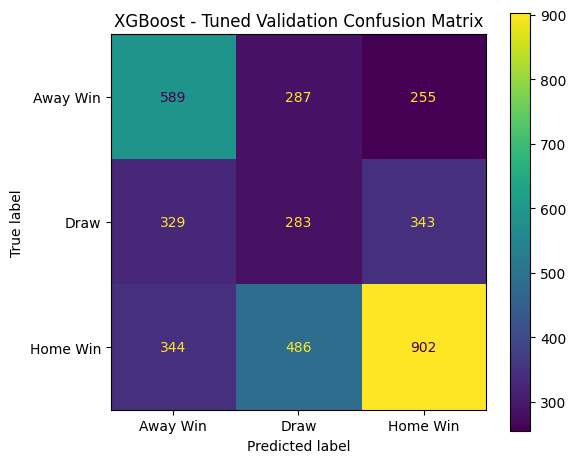

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val_encoded,
    y_val_pred_tuned,
    display_labels=target_encoder.classes_,
    ax=ax
)

plt.title(
    "XGBoost - Tuned Validation Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        XGB_DIR,
        "tuned_validation_confusion_matrix.png"
    ),
    dpi=300
)

plt.show()

Final Selected Features

In [ ]:
final_selector = (
    best_xgb_pipeline.named_steps["selector"]
)

final_classifier = (
    best_xgb_pipeline.named_steps["classifier"]
)

final_xgb_features = (
    X_train_corr.columns[
        final_selector.get_support()
    ].tolist()
)

print(
    "Final tuned XGBoost feature count:",
    len(final_xgb_features)
)

print("\nFinal selected XGBoost features:")

for i, feature in enumerate(
    final_xgb_features,
    start=1
):
    print(f"{i:2d}. {feature}")

Final tuned XGBoost feature count: 50

Final selected XGBoost features:
 1. home_win_rate
 2. home_draw_rate
 3. home_loss_rate
 4. home_goals_for_per_match
 5. home_goals_against_per_match
 6. home_home_win_rate
 7. home_home_draw_rate
 8. home_points_last3
 9. home_points_last5
10. home_points_last10
11. home_goals_for_last5
12. home_goals_for_last10
13. home_goals_against_last5
14. home_goals_against_last10
15. home_elo_before
16. away_win_rate
17. away_loss_rate
18. away_goals_for_per_match
19. away_goals_against_per_match
20. away_away_win_rate
21. away_away_draw_rate
22. away_away_goals_for_per_match
23. away_away_goals_against_per_match
24. away_points_last3
25. away_points_last10
26. away_goals_for_last3
27. away_goals_for_last10
28. away_elo_before
29. win_rate_difference
30. draw_rate_difference
31. goals_for_difference
32. goals_against_difference
33. venue_win_rate_difference
34. venue_goals_for_difference
35. venue_goals_against_difference
36. points_last3_difference
37. p

Feature Importance

In [ ]:
feature_importance_df = pd.DataFrame({

    "Feature": final_xgb_features,

    "Importance":
        final_classifier.feature_importances_

}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_df.head(30)
)

,Feature,Importance
0,elo_difference,0.143340
1,goals_for_difference,0.129289
2,venue_goals_for_difference,0.050855
3,win_rate_difference,0.044896
4,goals_against_difference,0.027523
5,venue_win_rate_difference,0.022390
6,goals_for_last10_difference,0.020627
7,away_win_rate,0.018750
8,home_points_last10,0.018626
9,away_loss_rate,0.018522


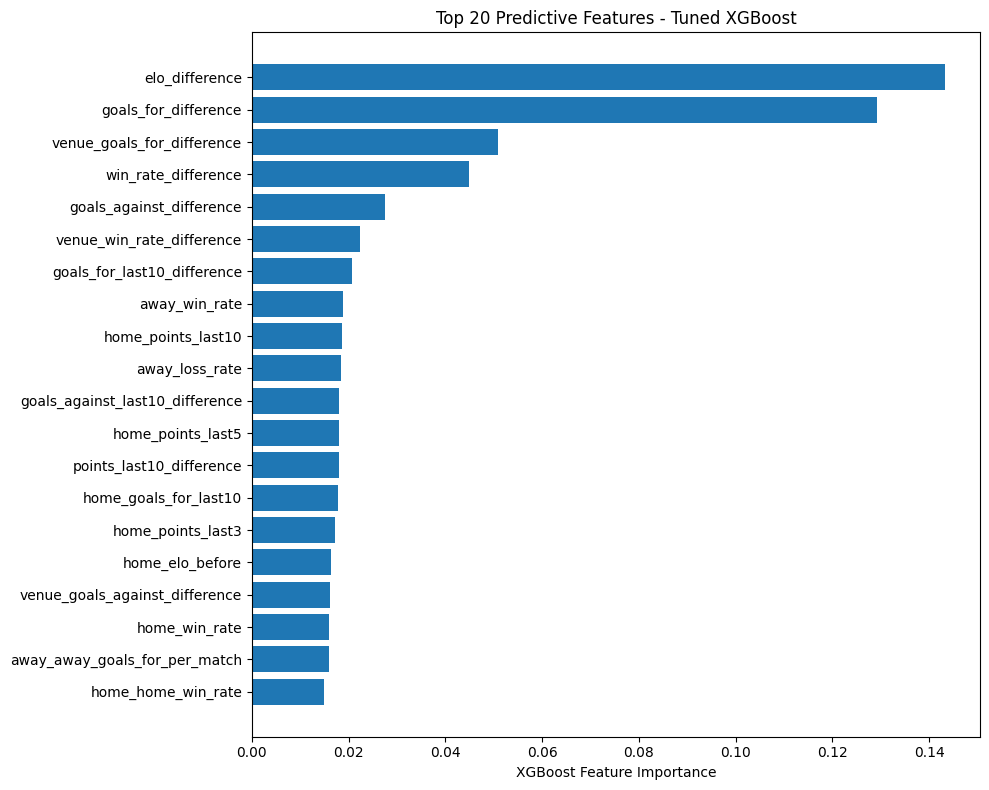

In [ ]:
top_20 = (
    feature_importance_df
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20["Feature"],
    top_20["Importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.title(
    "Top 20 Predictive Features - Tuned XGBoost"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        XGB_DIR,
        "top_20_feature_importances.png"
    ),
    dpi=300
)

plt.show()

Final Test Evaluation (applying calibrated draw threshold)

In [ ]:
y_test_proba = best_xgb_pipeline.predict_proba(X_test_corr)
y_test_pred = predict_with_draw_threshold(y_test_proba, threshold=best_threshold)

test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
test_macro_precision = precision_score(y_test_encoded, y_test_pred, average="macro", zero_division=0)
test_macro_recall = recall_score(y_test_encoded, y_test_pred, average="macro", zero_division=0)
test_macro_f1 = f1_score(y_test_encoded, y_test_pred, average="macro", zero_division=0)
test_weighted_f1 = f1_score(y_test_encoded, y_test_pred, average="weighted", zero_division=0)
test_roc_auc = roc_auc_score(y_test_encoded, y_test_proba, multi_class="ovr", average="weighted")

print("=" * 60)
print("FINAL XGBOOST TEST BENCHMARK (WITH DRAW THRESHOLDING)")
print("=" * 60)
print(f"Accuracy        : {test_accuracy:.4f}")
print(f"Macro Precision : {test_macro_precision:.4f}")
print(f"Macro Recall    : {test_macro_recall:.4f}")
print(f"Macro F1        : {test_macro_f1:.4f}")
print(f"Weighted F1     : {test_weighted_f1:.4f}")
print(f"ROC-AUC         : {test_roc_auc:.4f}")
print("=" * 60)

print("\nFinal Test Classification Report:")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

FINAL XGBOOST TEST BENCHMARK (WITH DRAW THRESHOLDING)
Accuracy        : 0.4532
Macro Precision : 0.4342
Macro Recall    : 0.4342
Macro F1        : 0.4331
Weighted F1     : 0.4568
ROC-AUC         : 0.6474

Final Test Classification Report:
              precision    recall  f1-score   support

    Away Win       0.43      0.48      0.46      1173
        Draw       0.28      0.30      0.29       980
    Home Win       0.59      0.52      0.55      1706

    accuracy                           0.45      3859
   macro avg       0.43      0.43      0.43      3859
weighted avg       0.46      0.45      0.46      3859



Majority Class Baseline Comparison

In [ ]:
majority_class = (
    y_train_encoded
    .value_counts()
    .idxmax()
)

majority_pred = np.full(
    len(y_test_encoded),
    majority_class
)

majority_accuracy = accuracy_score(
    y_test_encoded,
    majority_pred
)

majority_macro_f1 = f1_score(
    y_test_encoded,
    majority_pred,
    average="macro",
    zero_division=0
)

print("Majority-Class Baseline")
print("-" * 40)

print(
    f"Accuracy : {majority_accuracy:.4f}"
)

print(
    f"Macro F1 : {majority_macro_f1:.4f}"
)

print("\nXGBoost")
print("-" * 40)

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"Macro F1 : {test_macro_f1:.4f}"
)

Majority-Class Baseline
----------------------------------------
Accuracy : 0.4421
Macro F1 : 0.2044

XGBoost
----------------------------------------
Accuracy : 0.4532
Macro F1 : 0.4331


Predicetd vs Actual Class Distribution

In [ ]:
distribution_df = pd.DataFrame({

    "Actual": (
        y_test_encoded
        .value_counts(normalize=True)
        .sort_index()
    ),

    "Predicted": (
        pd.Series(y_test_pred)
        .value_counts(normalize=True)
        .sort_index()
    )
})

distribution_df.index = [
    target_encoder.classes_[i]
    for i in distribution_df.index
]

display(
    (distribution_df * 100).round(2)
)

,Actual,Predicted
Away Win,30.40,33.77
Draw,25.40,26.87
Home Win,44.21,39.36


Final Test Confusion Matrix

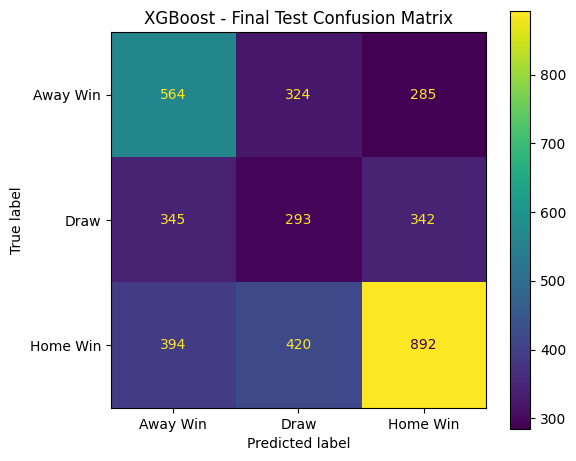

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_test_pred,
    display_labels=target_encoder.classes_,
    ax=ax
)

plt.title(
    "XGBoost - Final Test Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        XGB_DIR,
        "final_test_confusion_matrix.png"
    ),
    dpi=300
)

plt.show()

Final Summaary

In [ ]:
final_summary_df = pd.DataFrame({

    "Stage": [
        "Baseline Validation",
        "Tuned Validation",
        "Final Test"
    ],

    "Accuracy": [
        baseline_val_accuracy,
        tuned_val_accuracy,
        test_accuracy
    ],

    "Macro Precision": [
        baseline_macro_precision,
        tuned_macro_precision,
        test_macro_precision
    ],

    "Macro Recall": [
        baseline_macro_recall,
        tuned_macro_recall,
        test_macro_recall
    ],

    "Macro F1": [
        baseline_macro_f1,
        tuned_macro_f1,
        test_macro_f1
    ],

    "Weighted F1": [
        baseline_weighted_f1,
        tuned_weighted_f1,
        test_weighted_f1
    ],

    "ROC-AUC": [
        baseline_roc_auc,
        tuned_roc_auc,
        test_roc_auc
    ]
})

display(
    final_summary_df.round(4)
)

,Stage,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC
0,Baseline Validation,0.4688,0.4375,0.4444,0.4385,0.4670,0.6579
1,Tuned Validation,0.4646,0.4453,0.4460,0.4440,0.4694,0.6605
2,Final Test,0.4532,0.4342,0.4342,0.4331,0.4568,0.6474


Final Selected Feature Matrices

In [ ]:
X_train_xgb_final = X_train_corr[
    final_xgb_features
].copy()

X_val_xgb_final = X_val_corr[
    final_xgb_features
].copy()

X_test_xgb_final = X_test_corr[
    final_xgb_features
].copy()

print("Final XGBoost selected feature matrices:")

print("Training   :", X_train_xgb_final.shape)
print("Validation :", X_val_xgb_final.shape)
print("Test       :", X_test_xgb_final.shape)

assert len(X_train_xgb_final) == len(y_train_encoded)
assert len(X_val_xgb_final) == len(y_val_encoded)
assert len(X_test_xgb_final) == len(y_test_encoded)

assert (
    list(X_train_xgb_final.columns)
    == list(X_val_xgb_final.columns)
    == list(X_test_xgb_final.columns)
)

assert not X_train_xgb_final.isnull().any().any()
assert not X_val_xgb_final.isnull().any().any()
assert not X_test_xgb_final.isnull().any().any()

print(
    "Final dataset alignment and "
    "sanity checks passed."
)

Final XGBoost selected feature matrices:
Training   : (17294, 50)
Validation : (3818, 50)
Test       : (3859, 50)
Final dataset alignment and sanity checks passed.


Save Outputs

In [ ]:
X_train_xgb_final.to_csv(
    os.path.join(
        XGB_DIR,
        "X_train_xgboost.csv"
    ),
    index=False
)

X_val_xgb_final.to_csv(
    os.path.join(
        XGB_DIR,
        "X_validation_xgboost.csv"
    ),
    index=False
)

X_test_xgb_final.to_csv(
    os.path.join(
        XGB_DIR,
        "X_test_xgboost.csv"
    ),
    index=False
)

joblib.dump(
    best_xgb_pipeline,
    os.path.join(
        XGB_DIR,
        "xgboost_tuned_pipeline.joblib"
    )
)

joblib.dump(
    final_selector,
    os.path.join(
        XGB_DIR,
        "xgb_feature_selector.joblib"
    )
)

joblib.dump(
    corr_drop_columns,
    os.path.join(
        XGB_DIR,
        "correlation_dropped_columns.joblib"
    )
)

joblib.dump(
    final_xgb_features,
    os.path.join(
        XGB_DIR,
        "xgboost_selected_features.joblib"
    )
)

joblib.dump(
    best_threshold,
    os.path.join(
        XGB_DIR,
        "calibrated_draw_threshold.joblib"
    )
)

['/content/drive/MyDrive/ML Assignment/xgboost/calibrated_draw_threshold.joblib']

In [ ]:
pd.DataFrame({
    "Feature": final_xgb_features
}).to_csv(
    os.path.join(
        XGB_DIR,
        "xgboost_selected_features.csv"
    ),
    index=False
)

comparison_df.to_csv(
    os.path.join(
        XGB_DIR,
        "baseline_vs_tuned_validation.csv"
    ),
    index=False
)

final_summary_df.to_csv(
    os.path.join(
        XGB_DIR,
        "xgboost_lifecycle_results.csv"
    ),
    index=False
)

feature_importance_df.to_csv(
    os.path.join(
        XGB_DIR,
        "xgboost_feature_importance.csv"
    ),
    index=False
)

print(
    "All XGBoost outputs successfully saved."
)

All XGBoost outputs successfully saved.
